## Proyecto de Sprint 9

### Descripción del proyecto

Showz es una empresa de venta de entradas de eventos. La primera tarea es ayudar a optimizar los gastos de marketing. 

Se cuenta con:

- registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018;
- un archivo con los pedidos en este periodo;
- estadísticas de gastos de marketing.

Lo que se va a investigar: 

- cómo los clientes usan el servicio;
- cuándo empiezan a comprar;
- cuánto dinero aporta cada cliente a la compañía;
- cuándo los ingresos cubren el costo de adquisición de los clientes.



### 1 - Acceda los datos y prepáralos para el análisis

In [2]:
#Bibliotecas a importar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
#Importando los archivos CSV para convertirlos a DataFrame
costs = pd.read_csv('datasets/costs_us.csv')
orders = pd.read_csv('datasets/orders_log_us.csv')
visits = pd.read_csv('datasets/visits_log_us.csv')

In [4]:
#Primer analisis del DataFrame COSTS
costs.info()
display(costs.sample(5))
display(costs['costs'].describe())
costs.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


,source_id,dt,costs
2408,10,2018-01-16,9.89
860,3,2017-10-13,703.26
491,2,2017-10-07,161.63
2504,10,2018-04-24,26.10
2229,10,2017-07-21,17.52


count    2542.000000
mean      129.477427
std       156.296628
min         0.540000
25%        21.945000
50%        77.295000
75%       170.065000
max      1788.280000
Name: costs, dtype: float64

np.int64(0)

In [5]:
#Primer analisis del DataFrame ORDERS
orders.info()
display(orders.sample(5))
display(orders['Revenue'].describe())
orders.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


,Buy Ts,Revenue,Uid
30058,2018-01-19 13:25:00,14.67,9720597130025299137
17973,2017-11-16 23:02:00,0.23,8868843505020497916
43495,2018-04-08 15:53:00,1.22,12140873591922235603
7686,2017-09-13 19:20:00,0.73,784038927329970828
24597,2017-12-17 16:55:00,4.17,14860540473510559222


count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: Revenue, dtype: float64

np.int64(0)

In [6]:
#Primer analisis del DataFrame VISITS
visits.info()
display(visits.sample(5))
#display(visits.describe())
visits.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


,Device,End Ts,Source Id,Start Ts,Uid
1901,desktop,2018-03-19 12:45:00,10,2018-03-19 12:44:00,12491346332934232912
121487,touch,2017-10-13 07:44:00,2,2017-10-13 07:43:00,7291490258807467163
259399,desktop,2017-11-27 18:21:00,1,2017-11-27 17:36:00,1452409202090327183
273260,touch,2017-07-07 09:34:00,2,2017-07-07 09:30:00,16488492707700174059
239092,touch,2017-12-17 19:00:00,2,2017-12-17 18:53:00,6789782303646062407


np.int64(0)

    - Dando un primer vistazo a los DFs lo primero que observamos es que los nombres de las series no siguen una convención de nomenclaturas ya que cada palabra comienza con mayuscula y cuentan con espacios para separarlas, por lo que estos nombres serán modificados según la convención de Snake Case para estandarizar.
    - Los 3 DF aparentan no contar con datos nulos en ninguna de sus series.
    - No se encontraron registros duplicados dentro de los 3 DF, aun cuando por la naturaleza de las series se repiten los datos al analizar cada serie de forma individual.
    - Será necesario modificar las series DT en COSTS, BUY TS en ORDERS y [START TS, END TS] en VISITS que son de tipo Object para convertirlos a DateTime para poder utilizarlos más adelante.

In [7]:
#Aplicar snake_case a los nombres de las columnas
costs.columns = costs.columns.str.lower().str.replace(' ', '_')
orders.columns = orders.columns.str.lower().str.replace(' ', '_')
visits.columns = visits.columns.str.lower().str.replace(' ', '_')

costs.info()
orders.info()
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   device     359400 non-null  object
 1   end_ts     359400 non-null  object


In [8]:
#Modificamos el tipo de dato de la serie DT de COSTS a datetime
costs['dt'] = pd.to_datetime(costs['dt'], format='%Y-%m-%d')

#Modificamos el tipo de dato de la serie BUY_TS de ORDERS a datetime
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'], format='%Y-%m-%d %H:%M:%S')

#Modificamos el tipo de dato de la serie START_TS y END_TS de VISITS a datetime
visits['start_ts'] = pd.to_datetime(visits['start_ts'], format='%Y-%m-%d %H:%M:%S')
visits['end_ts'] = pd.to_datetime(visits['end_ts'], format='%Y-%m-%d %H:%M:%S')

### 2 - Haz informes y calcula métricas

#### 2.1 - Visitas

- ¿Cuántas personas lo usan cada día, semana y mes?
- ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
- ¿Cuál es la duración de cada sesión?
- ¿Con qué frecuencia los usuarios regresan?

In [9]:
#2.1.1 - Cantidad de usuarios únicos en VISITS por día, semana y mes
#Extraemos en nuevas series la fecha, semana y mes del DataFrame VISITS
visits['session_date'] = visits['start_ts'].dt.date
visits['session_week'] = visits['start_ts'].dt.isocalendar().week
visits['session_month'] = visits['start_ts'].dt.month
visits['session_year'] = visits['start_ts'].dt.isocalendar().year

#Calculamos DAU, WAU y MAU
dau_total = visits.groupby('session_date').agg({'uid': 'nunique'}).mean()
wau_total = visits.groupby(['session_year','session_week']).agg({'uid': 'nunique'}).mean()
mau_total = visits.groupby(['session_year','session_month']).agg({'uid': 'nunique'}).mean()

print('Usuarios únicos por día: ', int(dau_total.iloc[0]))
print('Usuarios únicos por semana: ', int(wau_total.iloc[0]))
print('Usuarios únicos por mes: ',int(mau_total.iloc[0]))

Usuarios únicos por día:  907
Usuarios únicos por semana:  5716
Usuarios únicos por mes:  23228


In [10]:
#2.1.2 - Cantidad de sesiones por día por usuario
sessions_per_user = visits.groupby(['session_year', 'session_month']).agg({'uid': ['count','nunique']})
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sessions_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']
print(sessions_per_user)

                            n_sessions  n_users  sessions_per_user
session_year session_month                                        
2017         6                   16505    13259           1.244815
             7                   17828    14183           1.256998
             8                   14355    11631           1.234202
             9                   23907    18975           1.259921
             10                  37903    29692           1.276539
             11                  43969    32797           1.340641
             12                  41983    31557           1.330386
2018         1                   36939    28716           1.286356
             2                   37182    28749           1.293332
             3                   35679    27473           1.298693
             4                   26515    21008           1.262138
             5                   26635    20701           1.286653


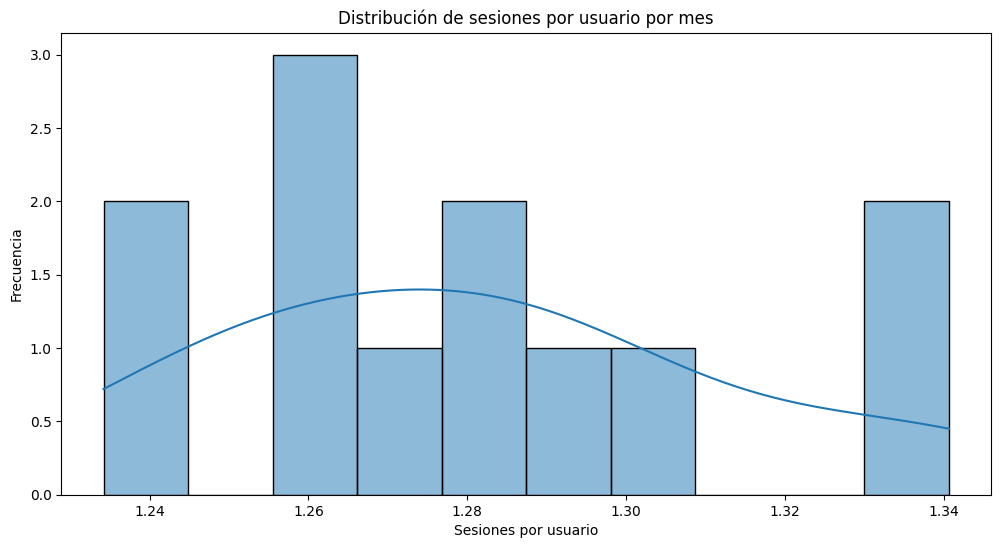

In [11]:
#Generamos un gráfico de campana de Gauss para visualizar la cantidad de sesiones por usuario por mes
plt.figure(figsize=(12, 6))
sns.histplot(data=sessions_per_user, x='sessions_per_user', bins=10, kde=True)
plt.title('Distribución de sesiones por usuario por mes')
plt.xlabel('Sesiones por usuario')
plt.ylabel('Frecuencia')
plt.show()

In [12]:
#2.1.3 - Duracion promedio de las sesiones
#Calculamos la duración en segundos de las sesiones restando el tiempo de START_TS a el tiempo de END_TS
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()
print(visits['session_duration'].describe())
print('Duración promedio en segundos de las sesiones: ', visits['session_duration'].mean())
print('Duración promedio en minutos de las sesiones: ', visits['session_duration'].mean()/60)
print('Duración promedio en segundos de las sesiones calculado con la moda: ', visits['session_duration'].mode())
print('Duración promedio en minutos de las sesiones calculado con la moda: ', visits['session_duration'].mode()/60)

count    359400.000000
mean        643.025687
std         997.127761
min       -2760.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
Name: session_duration, dtype: float64
Duración promedio en segundos de las sesiones:  643.0256872565387
Duración promedio en minutos de las sesiones:  10.717094787608978
Duración promedio en segundos de las sesiones calculado con la moda:  0    60.0
Name: session_duration, dtype: float64
Duración promedio en minutos de las sesiones calculado con la moda:  0    1.0
Name: session_duration, dtype: float64


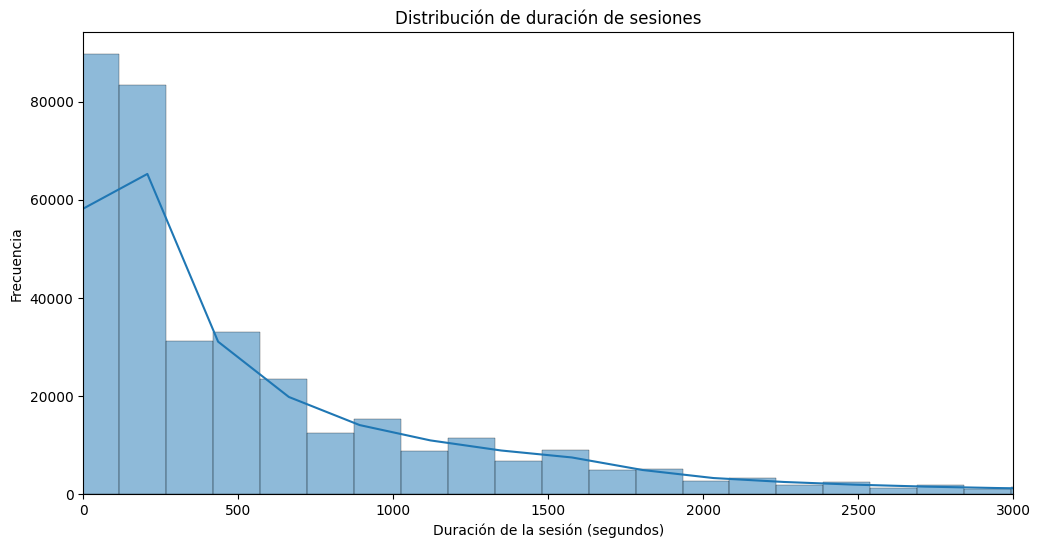

In [92]:
#Graficamos como histograma con la duración de las sesiones con un limite de x de 0 a 3000
plt.figure(figsize=(12, 6))
sns.histplot(data=visits, x='session_duration', bins=300, kde=True)
plt.xlim(0, 3000)
plt.title('Distribución de duración de sesiones')
plt.xlabel('Duración de la sesión (segundos)')
plt.ylabel('Frecuencia')
plt.show()

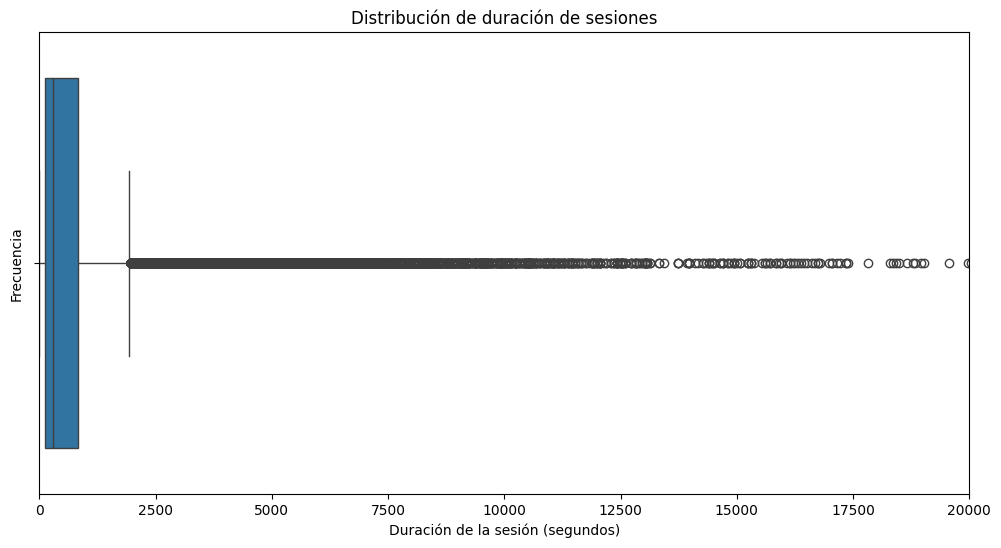

In [96]:
#Generamos un gráfico de boxplot para visualizar la duración de las sesiones con un limite de x de 0 a 20000
plt.figure(figsize=(12, 6))
sns.boxplot(data=visits, x='session_duration')
plt.xlim(0, 20000)
plt.title('Distribución de duración de sesiones')
plt.xlabel('Duración de la sesión (segundos)')
plt.ylabel('Frecuencia')
plt.show()

In [14]:
#2.1.4 - Frecuencia de los usuarios que regresan
#Calculamos el sticky factor semanal y mensual
sticky_factor_wau= dau_total / wau_total*100
sticky_factor_mau= dau_total / mau_total*100
print('Usuarios únicos diariamente: ', dau_total.iloc[0].round(0))
print('Frecuencia de los usuarios que regresan semanalmente: ', sticky_factor_wau.iloc[0].round(2),'%')
print('Frecuencia de los usuarios que regresan mensualmente: ', sticky_factor_mau.iloc[0].round(2),'%')

Usuarios únicos diariamente:  908.0
Frecuencia de los usuarios que regresan semanalmente:  15.88 %
Frecuencia de los usuarios que regresan mensualmente:  3.91 %


In [ ]:
#Calculamos la cantidad total de usuarios únicos del dispositivo desktop y touch
desktop_users = visits[visits['device'] == 'desktop'].groupby('session_date').agg({'uid': 'nunique'}).sum()
print('Cantidad total de usuarios únicos del dispositivo desktop: ', int(desktop_users.iloc[0]))
touch_users = visits[visits['device'] == 'touch'].groupby('session_date').agg({'uid': 'nunique'}).sum()
print('Cantidad total de usuarios únicos del dispositivo touch: ', int(touch_users.iloc[0]))

#Calculamos el promedio de sesiones por usuario por dispositivo
sessions_per_user_device = visits.groupby(['device', 'session_year', 'session_month']).agg({'uid': ['count','nunique']})
sessions_per_user_device.columns = ['n_sessions', 'n_users']
sessions_per_user_device['sessions_per_user'] = sessions_per_user_device['n_sessions'] / sessions_per_user_device['n_users']
sessions_per_user_device = sessions_per_user_device.reset_index()
sessions_per_user_device = sessions_per_user_device.pivot(index=['session_year', 'session_month'], columns='device', values='sessions_per_user')
print(sessions_per_user_device)
print(sessions_per_user_device.mean())

Cantidad total de usuarios únicos:  359400
Cantidad total de usuarios únicos del dispositivo desktop:  239965
Cantidad total de usuarios únicos del dispositivo touch:  91793
device                       desktop     touch
session_year session_month                    
2017         6              1.266059  1.134610
             7              1.276491  1.155103
             8              1.260481  1.117816
             9              1.284773  1.153548
             10             1.286855  1.186879
             11             1.346905  1.239987
             12             1.335623  1.237450
2018         1              1.305995  1.185448
             2              1.316079  1.176368
             3              1.321191  1.182464
             4              1.295540  1.140442
             5              1.319312  1.166391
device
desktop    1.301275
touch      1.173042
dtype: float64


    - Se registran en promedio 908 visitas de usuarios distintos al día, sin embargo al trazar una tendencia semanal y mensual (30 días) de este promedio diario existe una disminución del 10% en el conteo semanal con 5176 y de un 15% en el mensual con 23228 visitas.
    - Dentro del año de analisis 06/2017 al 05/2018 se encontraron que los meses con más usuarios son Noviembre y Diciembre mientras que los de menor cantidad son Junio y Agosto.
    - Al gráficar la distribución de sesiones del año confirmamos que la temporada invernal registra la mayor cantidad de sesiones que el resto del año.
    - La duración promedio de una visita de un usuario a la página web es de alrededor de 643 segundos y encontramos que el 50% de total de usarios se concentran en los 300 segundos y el 75% en 840 segundos; sin embargo al calcular este promedio con base en la MODA es de alrededor de 60 segundos.
    - Y tal como se comentó incialmente existe una tendencia ala baja en los usuarios que visitan la página a la semana y al mes, y al calcular el sticky factor recalcamos este comportamiento ya que de los 908 usuarios unicos que visitan la página solo el 16% regresa a la semana y un 4% al mes.
    - Como dato adicional se calculó el promedio de sesiones mensuales desde PC o dispositivo móvil y se encontró que los usuarios acceden en mayor parte desde una PC al sitio que desde un dispositivo móvil.

### 2.2 - Ventas

- ¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)
- ¿Cuántos pedidos hacen durante un período de tiempo dado?
- ¿Cuál es el tamaño promedio de compra?
- ¿Cuánto dinero traen? (LTV)

In [16]:
#2.2.1 - Dias de conversion de registro a primera compra
#Creamos un nuevo DataFrame para almacenar la fecha de la primera visita
first_visit = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()
first_visit.columns = ['uid', 'first_visit']

#Se crea el nuevo DataFrame ORDERS_WITH_FIRST_VISITS para almacenar la union de FIRST_VISIT y ORDERS por UID
#Luego generamos una nueva serie CONVERSION_DELAY que almacena la diferencia entre la fecha de compra y la fecha de primera visita
orders_with_first_visits = orders.merge(first_visit, on='uid', how='left')
orders_with_first_visits['conversion_delay'] = (orders_with_first_visits['buy_ts'] - orders_with_first_visits['first_visit']).dt.days

#Empezamos la division en cohortes por días de conversion
#Creamos una nueva serie CONVERSION_COHORT que almacena un string con la cantidad de días de conversion
orders_with_first_visits['conversion_cohort'] = 'Conversion ' + orders_with_first_visits['conversion_delay'].astype(str) + 'd'

#Imprimimos el top 10 de la cantidad de conversiones al contar los valores repetidos de la serie CONVERSION_COHORT 
print(orders_with_first_visits['conversion_cohort'].sort_values().value_counts().head(10))
orders_with_first_visits['conversion_delay'].describe()

conversion_cohort
Conversion 0d     28103
Conversion 1d      1422
Conversion 2d       837
Conversion 3d       628
Conversion 4d       532
Conversion 5d       434
Conversion 6d       426
Conversion 7d       354
Conversion 8d       304
Conversion 10d      258
Name: count, dtype: int64


count    50415.000000
mean        36.788238
std         70.490602
min          0.000000
25%          0.000000
50%          0.000000
75%         38.000000
max        364.000000
Name: conversion_delay, dtype: float64

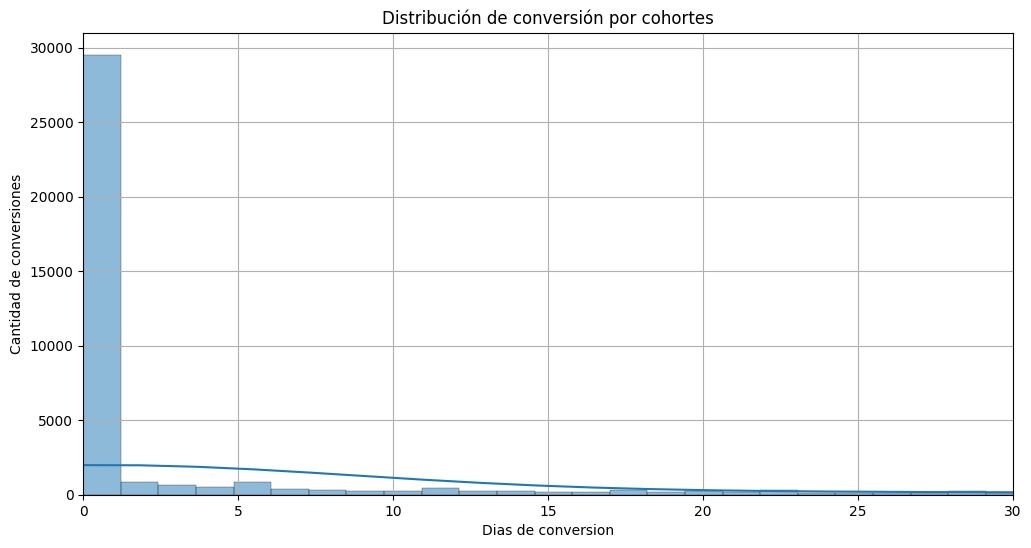

In [17]:
#Graficamos una campana de Gauss para ver la distribucion de las conversiones y comparar los cohortes
#Limitamos el eje x a 30 dias para una mejor visibilidad de los datos
plt.figure(figsize=(12, 6))
sns.histplot(orders_with_first_visits['conversion_delay'], bins=300, kde=True)
plt.xlim(0, 30)
plt.title('Distribución de conversión por cohortes')
plt.xlabel('Dias de conversion')
plt.ylabel('Cantidad de conversiones')
plt.grid()
plt.show()

In [18]:
#Calculamos la cantidad de clientes que compran más de una vez
#Creamos un nuevo DataFrame para almacenar la cantidad de compras por UID
orders_per_user = orders.groupby('uid').agg({'buy_ts': 'count'}).reset_index()
orders_per_user.columns = ['uid', 'n_orders']
#Creamos una nueva serie que almacena la cantidad de usuarios que compran más de una vez
orders_per_user['n_orders'] = orders_per_user['n_orders'].apply(lambda x: 1 if x > 1 else 0)
print('Cantidad de usuarios que han comprado más de una vez: ', orders_per_user['n_orders'].sum())

Cantidad de usuarios que han comprado más de una vez:  6292


In [19]:
#2.2.2 - Pedidos realizados durante un periodo de tiempo (meses)
#Creamos un DF FIRST_PURCHASE_DATES con la fecha de la primera compra por usuario para luego unirlo al DF ORDERS
first_purchase_dates = orders.groupby('uid')['buy_ts'].min()
first_purchase_dates.name = 'first_purchase_date'
orders_per_month = orders.merge(first_purchase_dates, on='uid', how='left')

#Separamos los meses de las series FIRST_PURCHASE_DATE y BUY_TS
orders_per_month['first_purchase_month'] = orders_per_month['first_purchase_date'].dt.to_period('M')
orders_per_month['order_month'] = orders_per_month['buy_ts'].dt.to_period('M')

#Dividimos ORDERS en cohortes por mes y calculamos la cantidad de usuarios únicos, la cantidad de pedidos y el revenue por cohorte
cohorts = orders_per_month.groupby('first_purchase_month').agg({'uid': 'nunique', 'revenue': 'sum', 'buy_ts': 'count'})
cohorts.columns = ['n_users', 'revenue', 'n_orders']
print(cohorts)

                      n_users   revenue  n_orders
first_purchase_month                             
2017-06                  2023  24031.69      4438
2017-07                  1923  16127.92      2910
2017-08                  1370  11606.26      2188
2017-09                  2581  34676.32      3878
2017-10                  4340  27603.45      6005
2017-11                  4081  26098.99      5900
2017-12                  4383  33485.74      5894
2018-01                  3373  16663.13      4308
2018-02                  3651  16750.50      4470
2018-03                  3533  19273.41      4484
2018-04                  2276  11810.61      2690
2018-05                  2988  13925.76      3249
2018-06                     1      3.42         1


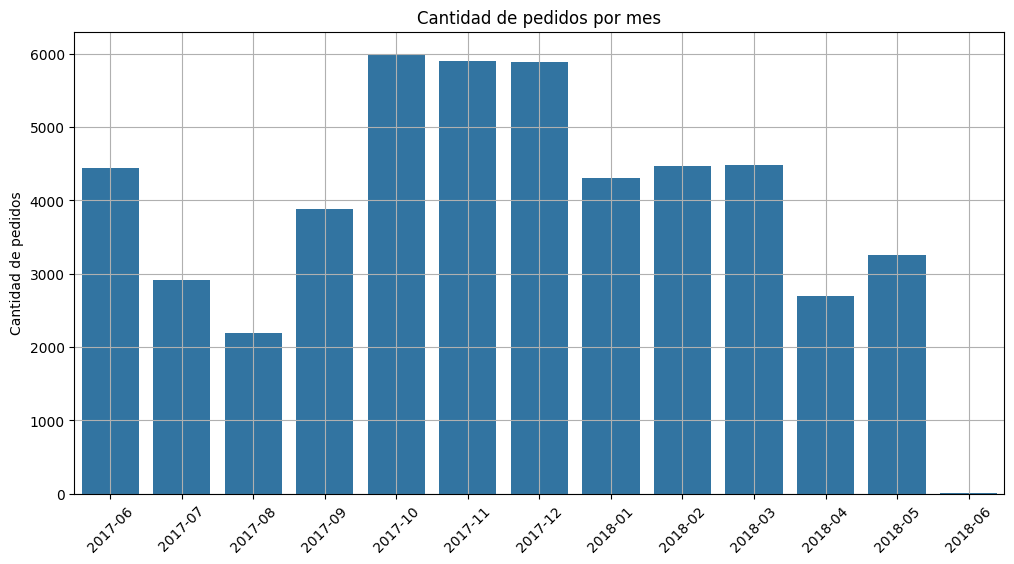

In [86]:
#Generamos un gráfico de barras para visualizar la cantidad de pedidos por mes
plt.figure(figsize=(12, 6))
sns.barplot(data=cohorts.reset_index(), x='first_purchase_month', y='n_orders')
plt.title('Cantidad de pedidos por mes')
plt.xlabel(None)
plt.ylabel('Cantidad de pedidos')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [21]:
#2.2.3 - Valor promedio del pedido AOV
#Calculamos el tamaño promedio de compra dividiendo el revenue por la cantidad de pedidos
cohorts['aov'] = cohorts['revenue'] / cohorts['n_orders']
print(cohorts['aov'])
print('Tamaño promedio de compra: ', cohorts['aov'].mean().round(2))

first_purchase_month
2017-06    5.414982
2017-07    5.542241
2017-08    5.304506
2017-09    8.941805
2017-10    4.596744
2017-11    4.423558
2017-12    5.681327
2018-01    3.867950
2018-02    3.747315
2018-03    4.298263
2018-04    4.390561
2018-05    4.286168
2018-06    3.420000
Freq: M, Name: aov, dtype: float64
Tamaño promedio de compra:  4.92


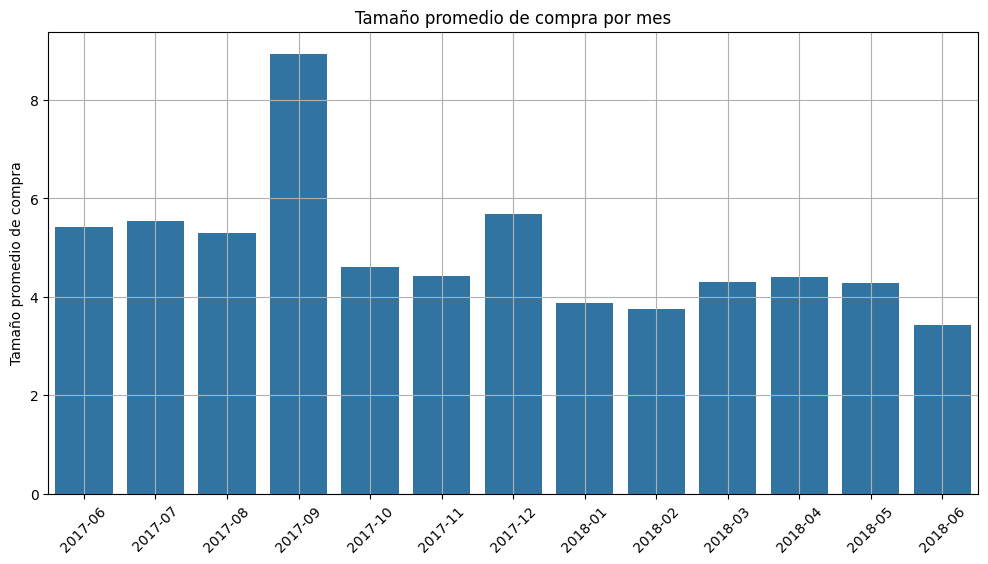

In [87]:
#Grafica de barras para visualizar el tamaño promedio de compra por mes
plt.figure(figsize=(12, 6))
sns.barplot(data=cohorts.reset_index(), x='first_purchase_month', y='aov')
plt.title('Tamaño promedio de compra por mes')
plt.xlabel(None)
plt.ylabel('Tamaño promedio de compra')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [23]:
#2.2.4 - Calculo del beneficio bruto por cliente (LTV)
#Creamos una nueva serie LTV que almacena el revenue dividido por la cantidad de usuarios únicos
cohorts['ltv'] = cohorts['revenue'] / cohorts['n_users']
print(cohorts['ltv'])
print('Beneficio bruto por cliente: ', cohorts['ltv'].mean().round(2))

first_purchase_month
2017-06    11.879234
2017-07     8.386854
2017-08     8.471723
2017-09    13.435227
2017-10     6.360242
2017-11     6.395244
2017-12     7.639913
2018-01     4.940151
2018-02     4.587921
2018-03     5.455253
2018-04     5.189196
2018-05     4.660562
2018-06     3.420000
Freq: M, Name: ltv, dtype: float64
Beneficio bruto por cliente:  6.99


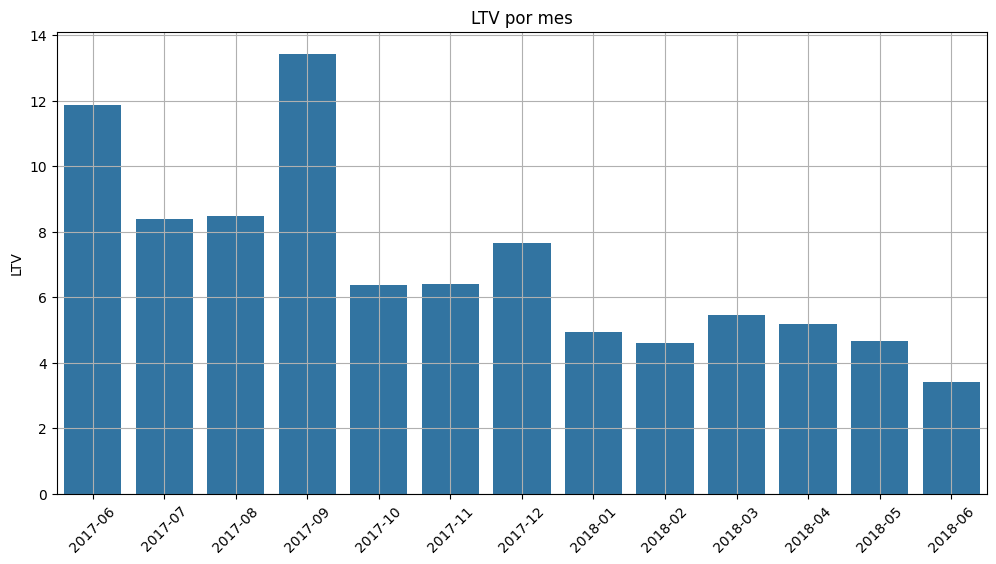

In [88]:
#Generamos un gráfico de barras para visualizar el LTV por mes
plt.figure(figsize=(12, 6))
sns.barplot(data=cohorts.reset_index(), x='first_purchase_month', y='ltv')
plt.title('LTV por mes')
plt.xlabel(None)
plt.ylabel('LTV')
plt.xticks(rotation=45)
plt.grid()
plt.show()

    - Analizando los días de conversión de prospectos a clientes encontramos que más del 50% de los usuarios compran el mismo día que entran por primera vez a la página web, el siguiente 25% compra dentro de los primeros 38 días y de ahí en adelante se distribuye el ultimo del 25% del total de usuarios.
    - Esto queda reflajado a la perfección en la gráfica titulada "Distribución de conversión por cohortes" en la que notamos la tan marcada tendencia a la baja a partir del día 0 en adelante.
    - De igual forma se calculó la cantidad de usuarios que realizan más de una compra siendo solo del 12% del total de usuarios los que han regresado.
    - Calculando la cantidad de pedidos por mes, recalcamos lo previamente mencionado de que son los ultimos 3 meses del 2017 la temporada con la mayor cantidad de pedidos, ganancias y usuarios. 
    - De igual forma se encontró que el AOV (valor promedio de compra) es de $4.92; mientras que el LTV (beneficio bruto por cliente) es de $6.99. Esto contradice los meses con mejores revenues ya que tanto las graficas del AOV como del LTV muestran su pico más alto en el 09-2017, confirmando que aunque el ultimo trimestre del año tiene mejores número de forma general se tiene un mayor beneficio en Agosto.


### 2.3 - Marketing

- ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 
- ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
- ¿Cuán rentables eran las inversiones? (ROMI)

In [82]:
#2.3.1 - Cantidad gastada por fuente de adquisición
#Creamos un nuevo DataFrame para calcular el costo de adquisición por fuente
acquisition_costs = costs.groupby('source_id').agg({'costs': 'sum'}).reset_index()
acquisition_costs['costs'] = acquisition_costs['costs'].apply(lambda x: round(x, 2))
acquisition_costs['costs'] = acquisition_costs['costs'].astype(float)

#Calculamos la candidad de usuarios únicos por fuente de adquisición
acquisition_costs = acquisition_costs.merge(visits.groupby('source_id')['uid'].nunique().reset_index(), on='source_id', how='left')
acquisition_costs.columns = ['source_id', 'costs', 'n_users']
print(acquisition_costs)

   source_id      costs  n_users
0          1   20833.27    18999
1          2   42806.04    26245
2          3  141321.63    74756
3          4   61073.60    83525
4          5   51757.10    56974
5          9    5517.49     9264
6         10    5822.49     8067


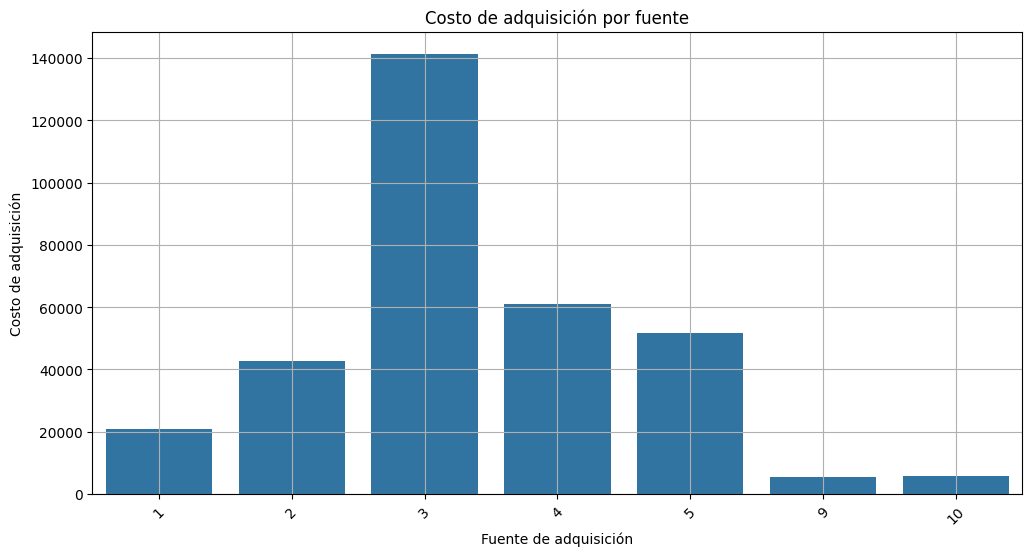

In [26]:
#Generamos un gráfico de barras para visualizar el costo de adquisición por fuente
plt.figure(figsize=(12, 6))
sns.barplot(data=acquisition_costs, x='source_id', y='costs')
plt.title('Costo de adquisición por fuente')
plt.xlabel('Fuente de adquisición')
plt.ylabel('Costo de adquisición')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [27]:
#2.3.2 - Costo de adquisición CAC por fuente    
#Creamos un nuevo DataFrame para calcular el CAC por fuente
acquisition_costs['cac'] = acquisition_costs['costs'] / acquisition_costs['n_users']
print(acquisition_costs)

   source_id      costs  n_users       cac
0          1   20833.27    18999  1.096546
1          2   42806.04    26245  1.631017
2          3  141321.63    74756  1.890439
3          4   61073.60    83525  0.731201
4          5   51757.10    56974  0.908434
5          9    5517.49     9264  0.595584
6         10    5822.49     8067  0.721766


In [67]:
#2.3.3 - ROMI por fuente
# Obtener fuente de adquisición inicial por usuario, agregamos la serie de device
first_sources = visits.groupby('uid').agg({'source_id': 'first', 'device': 'first'}).reset_index()
first_sources.columns = ['uid', 'source_id', 'device']

# Asociar fuente de adquisición con orden
orders_with_source = orders.merge(first_sources, on='uid')

# Ingresos por fuente
revenue_per_source = orders_with_source.groupby('source_id')['revenue'].sum()
revenue_per_source = revenue_per_source.reset_index()
revenue_per_source.columns = ['source_id', 'revenue']

#Agrupamos en un nuevo DF costo de adquisición con revenue por fuente
revenue_vs_costs = acquisition_costs.merge(revenue_per_source, on='source_id', how='left')

#Calculamos el LTV por fuente
revenue_vs_costs['ltv'] = revenue_vs_costs['revenue'] / revenue_vs_costs['n_users']

#Calculamos el ROMI por fuente
revenue_vs_costs['romi'] = (revenue_vs_costs['revenue'] - revenue_vs_costs['costs']) / revenue_vs_costs['costs']
revenue_vs_costs['romi'] = revenue_vs_costs['romi'].apply(lambda x: round(x, 2))
revenue_vs_costs['romi'] = revenue_vs_costs['romi'].astype(float)
print(revenue_vs_costs)

   source_id      costs  n_users       cac   revenue       ltv  romi
0          1   20833.27    18999  1.096546  38560.06  2.029584  0.85
1          2   42806.04    26245  1.631017  65152.26  2.482464  0.52
2          3  141321.63    74756  1.890439  44317.68  0.592831 -0.69
3          4   61073.60    83525  0.731201  52479.75  0.628312 -0.14
4          5   51757.10    56974  0.908434  40357.91  0.708357 -0.22
5          9    5517.49     9264  0.595584   7076.98  0.763923  0.28
6         10    5822.49     8067  0.721766   4111.34  0.509649 -0.29


/tmp/ipykernel_31356/55331398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_vs_costs, x='source_id', y='romi', palette=['blue' if x > 0 else 'red' for x in revenue_vs_costs['romi']])


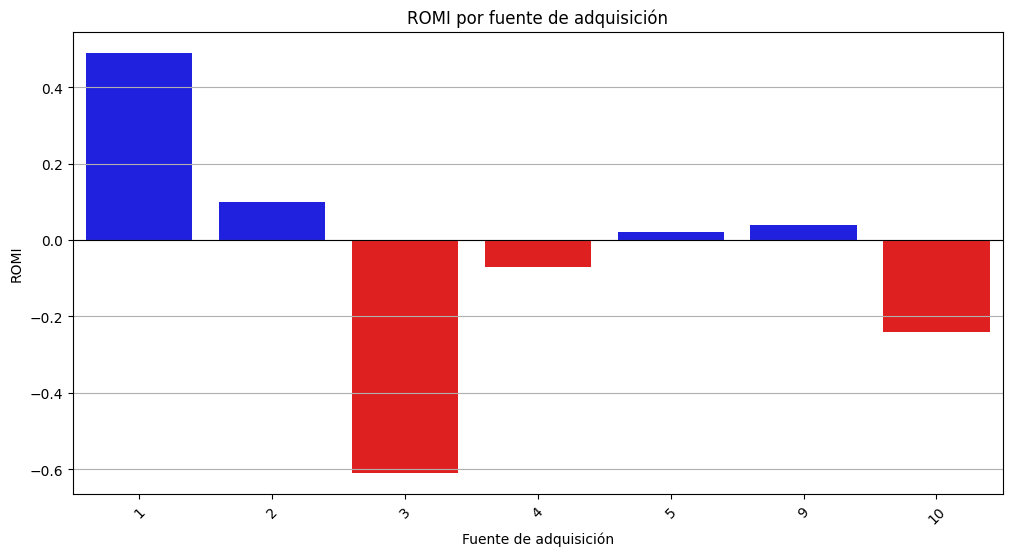

In [61]:
#Generamos una gŕafica de barras con base a la serie ROMI del DF revenue vs costs por fuente
#Las barras positivas serán de color azul y las negativas de color rojo
plt.figure(figsize=(12, 6))
sns.barplot(data=revenue_vs_costs, x='source_id', y='romi', palette=['blue' if x > 0 else 'red' for x in revenue_vs_costs['romi']])
plt.title('ROMI por fuente de adquisición')
plt.xlabel('Fuente de adquisición')
plt.ylabel('ROMI')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

In [112]:
#Agrupamos en un nuevo dataframe orders_with_source por device y source_id
devices_with_source = orders_with_source.groupby(['device', 'source_id']).agg({'revenue': 'sum', 'uid': 'nunique'}).reset_index()
devices_with_source.columns = ['device', 'source_id', 'revenue', 'n_users']
#Unimos el DF devices_with_source con el DF acquisition_costs para obtener el costo de adquisición por fuente
devices_with_source = devices_with_source.merge(acquisition_costs[['source_id', 'costs']], on='source_id', how='left')
devices_with_source['cac'] = devices_with_source['costs'] / devices_with_source['n_users']
devices_with_source['ltv'] = devices_with_source['revenue'] / devices_with_source['n_users']
devices_with_source['romi'] = (devices_with_source['revenue'] - devices_with_source['costs']) / devices_with_source['costs']
devices_with_source['romi'] = devices_with_source['romi'].apply(lambda x: round(x, 2))
devices_with_source['romi'] = devices_with_source['romi'].astype(float)

#Separamos en un nuevo DF devices_with_source por DESKTOP
devices_with_source_desktop = devices_with_source[devices_with_source['device'] == 'desktop']
devices_with_source_desktop = devices_with_source_desktop.drop(columns=['device'])
devices_with_source_desktop = devices_with_source_desktop.reset_index(drop=True)
print('Fuentes de adquisición del dispositivo DESKTOP', '\n', devices_with_source_desktop,'\n')

#Separamos en un nuevo DF devices_with_source por TOUCH
devices_with_source_touch = devices_with_source[devices_with_source['device'] == 'touch']
devices_with_source_touch = devices_with_source_touch.drop(columns=['device'])
devices_with_source_touch = devices_with_source_touch.reset_index(drop=True)
print('Fuentes de adquisición del dispositivo TOUCH', '\n',devices_with_source_touch)

#A

Fuentes de adquisición del dispositivo DESKTOP 
    source_id   revenue  n_users      costs        cac        ltv  romi
0          1  32394.35     2893   20833.27   7.201269  11.197494  0.55
1          2  56679.58     3290   42806.04  13.010954  17.227836  0.32
2          3  37467.44     7645  141321.63  18.485498   4.900908 -0.73
3          4  40615.41     7596   61073.60   8.040232   5.346947 -0.33
4          5  35067.56     5665   51757.10   9.136293   6.190214 -0.32
5          7      1.22        1        NaN        NaN   1.220000   NaN
6          9   5938.57     1143    5517.49   4.827200   5.195599  0.08
7         10   3367.68      989    5822.49   5.887250   3.405137 -0.42 

Fuentes de adquisición del dispositivo TOUCH 
    source_id   revenue  n_users      costs        cac       ltv  romi
0          1   6165.71      850   20833.27  24.509729  7.253776 -0.70
1          2   8472.68     1033   42806.04  41.438567  8.202014 -0.80
2          3   6850.24     1493  141321.63  94.656149

/tmp/ipykernel_31356/1043264893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=devices_with_source_desktop, x='source_id', y='romi', palette=['blue' if x > 0 else 'red' for x in devices_with_source_desktop['romi']])


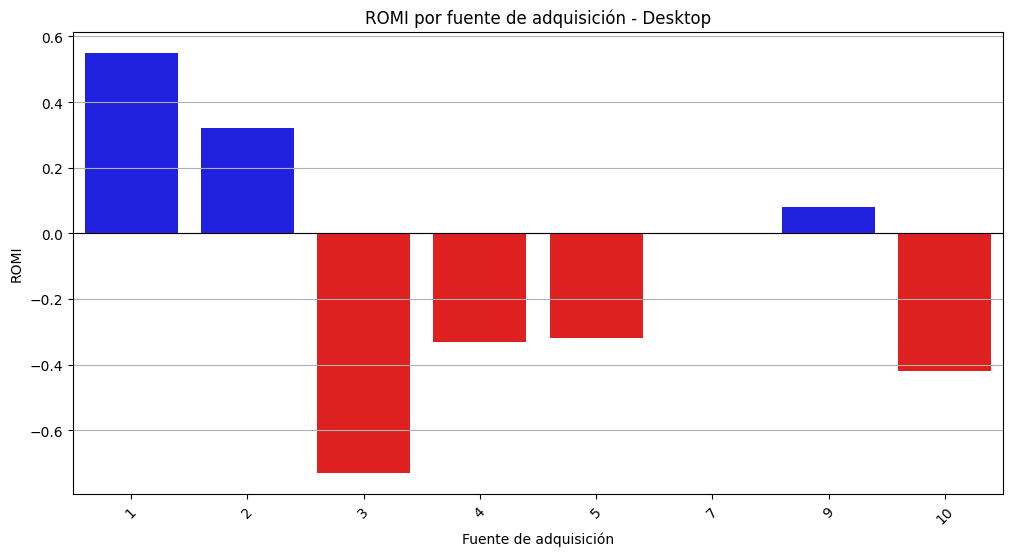

In [84]:
#Graficamos el ROMI por fuente de adquisición para el dispositivo DESKTOP
plt.figure(figsize=(12, 6))
sns.barplot(data=devices_with_source_desktop, x='source_id', y='romi', palette=['blue' if x > 0 else 'red' for x in devices_with_source_desktop['romi']])
plt.title('ROMI por fuente de adquisición - Desktop')
plt.xlabel('Fuente de adquisición')
plt.ylabel('ROMI')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_31356/1895408465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=devices_with_source_mobile, x='source_id', y='romi', palette=['blue' if x > 0 else 'red' for x in devices_with_source_mobile['romi']])


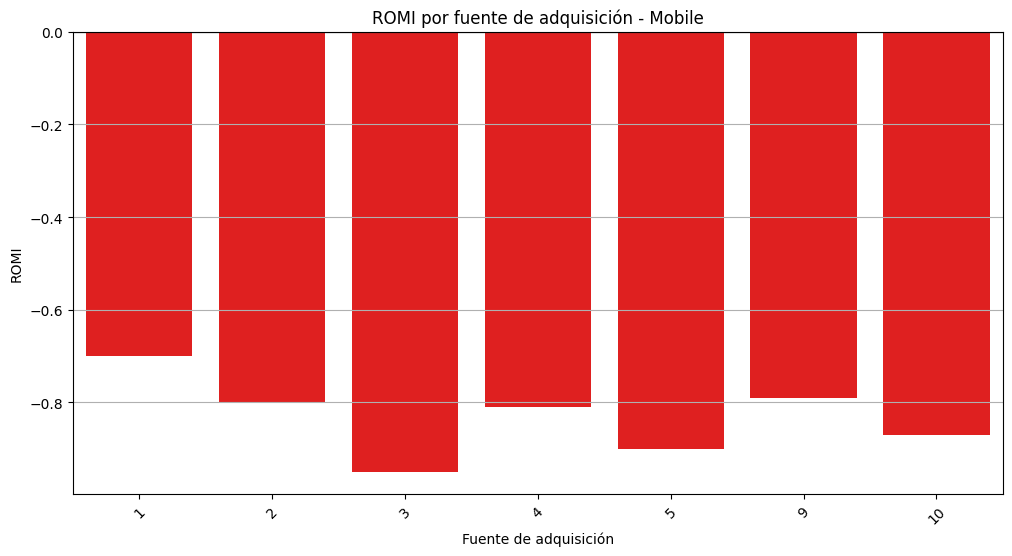

In [85]:
#Graficamos el ROMI por fuente de adquisición para el dispositivo TOUCH
plt.figure(figsize=(12, 6))
sns.barplot(data=devices_with_source_mobile, x='source_id', y='romi', palette=['blue' if x > 0 else 'red' for x in devices_with_source_mobile['romi']])
plt.title('ROMI por fuente de adquisición - Mobile')
plt.xlabel('Fuente de adquisición')
plt.ylabel('ROMI')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.show()

    - Revisando los costos por cada campaña de marketing encontramos que la campaña más cosotosa es la que tiene el identificador 3, mientras que la menos es la número 9. Esto queda más que confirmado al calcular el CAC (costo de adquisicion por cliente) siendo la campaña 3 un costo de $1.89 y generando la segunda mayor cantidad de usuarios y revenue; por otro lado la campaña 9 con un CAD de $0.60 obtuvo el penultimo lugar en usuarios adquiridos e igual posición de revenue.
    - Ahora lo importante es conocer el ROMI (retorno de la inversión en marketing) de cada fuente de adquisición, en la que encontramos que la que tiene el mejor desempeño con un valor 0.49 es la campaña número 1 y la de peor retorno de la inversión es la fuente 3 con un valor de -0.61.
    - Si nos enfocamos en el ROMI de cada fuente de adquisición de cada tipo de dispositivo desde los que acceden los clientes DESKTOP o TOUCH (MOBILE); identificamos que DEKSTOP sigue el comportamiento general del ROMI siendo nuevamente la campaña más exitosa la 1 y la menos la número 3; sin embargo notamos de forma alarmante que para el dispositivo TOUCH, ninguna de las campañas tuvo un desempeño positivo.

### 4 - Conclusiones

A continuación se expondrán las recomendaciones finales sobre las inversiones de marketing:

    + Es necesario enfocar las inversiones en el ultimo trimestre del año ya que es la temporada en la que contamos con la mayor cantidad de usuarios, revenue y pedidos; es necesario buscar incrementar el tamaño promedio del pedido para no desgastarse en atender multiples pedidos de poca ganancia tal como se ve reflejado en el LTV mensual.
    + La conversión de los prospectos a clientes dentro del mismo día es excelente ya que más del 50% de los usuarios presentan este comportamiento, sin embargo es necesario buscar campañas concentradas en cerrar las ventas dentro de los primeros 7 días ya que sabemos que el resto de los usuarios compran dentro de los siguientes 38 días o más haciendo que esta probabilidad de venta se reduzca gravemente conforme avanza el tiempo.
    + Al saber que el DESKTOP es el dispositivo utilizado por el 66% de los usuarios para acceder al sitio y al reconocer que solo las fuentes de adqisición aplicadas en este dispositivo han generado un desempeño positivo es de suma importancia focalizar nuestros esfuerzos en este dispositivo para enganchar por más tiempo a los clientes y guiarlos a compras rápidas y bien informadas.
    + Las fuentes de adquisición 1,3 y 9 que han generado un desempeño y retorno de inversión positivos deberán ser la prioridad en espcial las fuentes 1 y 2 que si bien no son las que generan la mayor cantidad de revenue o users realmente cargan con las ventas y deberían de ser las que reciban mayor inversión para buscar hacerlas cerecer.

    - La mayoria de los usuarios duran menos de 5 minutos en el sitio y se tendrían que generar estrategias para buscar el cierre rápido de las ventas o la retención de estos usuarios, de igual forma es una señal de alarma los usuarios que duran 30 miutos o más ya que solo generan ruido en los promedios de duración de las sesiones, por lo que la implementación de una función de cierre de sesion automático de no actividad en el sitio es fundamental.
    - Se deben aplicar campañas de fidelización con los clientes para que regresen a la página y compren, ya que solo un 16% de los usuarios regresan semanalmente y un 4% vuelven al mes; así como solo un 16% de los usuarios han realizado al menos una segunda compra.
    - Si bien el 40% de los usarios accede desde un dispositivo TOUCH está más que demostrado que ninguna de las fuentes de adquisición ha dado algún rendimiento positivo sino que al contrario han sido un gasto abusrdo ya que el ROMI de todas ronda el -60% o más, por lo que se tendrían que reducir al máximo la inversión en las fuentes de adquisición.
    - En la generalidad de las fuentes de adquisición es necesario evaluar la modificación o eliminación de las fuentes 3,4 y 10 que generan un retorno de la inversión negativo, especielmente se recomienda reformar las fuentes 3 y 4 que generan una alta cantidad de usuarios, pedidos y rendimientos a un costo demasiado alto.